# Statoil/C-CORE Iceberg vs Ship Classifier — GPU PyTorch Notebook

This notebook trains a GPU-based convolutional neural network to predict whether a 75×75 SAR image contains an **iceberg** (`1`) or a **ship** (`0`).

It uses:

- `band_1`, `band_2`, and a derived third channel: `band_1 - band_2`
- cleaned `inc_angle` as tabular metadata
- stratified K-fold validation
- PyTorch CNN with mixed precision GPU training
- test-time augmentation
- submission file generation

Expected files in the working directory:

```text
train.json
test.json
sample_submission.csv
```

On Kaggle, these are usually under something like:

```text
/kaggle/input/statoil-iceberg-classifier-challenge/
```

## 1. Setup

Run this first. The notebook will automatically use CUDA if available.

In [13]:
import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4070


## 2. Config

Update `DATA_DIR` if your files are somewhere else.

In [14]:
DATA_DIR = Path("./statoil-iceberg-classifier-challenge/data/statoil-iceberg-classifier-challenge")

TRAIN_PATH = DATA_DIR / "train.json/train.json"
TEST_PATH = DATA_DIR / "test.json/test.json"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv/sample_submission.csv"

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CFG = {
    "img_size": 75,

    # We are upgrading from 3 channels to 5 engineered SAR channels
    "channels": 5,

    # Aggressive but still reasonable
    "batch_size": 24,
    "epochs": 80,
    "n_folds": 5,
    "patience": 15,

    # Optimizer
    "lr": 7e-4,
    "weight_decay": 2e-4,

    # Regularization
    "dropout": 0.50,
    "label_smoothing": 0.04,
    "grad_clip": 1.0,

    # Notebook-safe DataLoader
    "num_workers": 0,
    "pin_memory": False,

    # TTA
    "tta": True,

    # Prediction clipping for log loss
    "pred_clip": 0.001,
}

print("Train exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test exists:", TEST_PATH.exists(), TEST_PATH)
print("Sample exists:", SAMPLE_PATH.exists(), SAMPLE_PATH)

Train exists: True statoil-iceberg-classifier-challenge\data\statoil-iceberg-classifier-challenge\train.json\train.json
Test exists: True statoil-iceberg-classifier-challenge\data\statoil-iceberg-classifier-challenge\test.json\test.json
Sample exists: True statoil-iceberg-classifier-challenge\data\statoil-iceberg-classifier-challenge\sample_submission.csv\sample_submission.csv


## 3. Load data

Each image has two flattened 75×75 radar bands. We reshape them and create a third engineered channel.

In [15]:
train_df = pd.read_json(TRAIN_PATH)
test_df = pd.read_json(TEST_PATH)

print(train_df.shape, test_df.shape)
train_df.head()

(1283, 5) (321, 4)


,id,band_1,band_2,inc_angle,is_iceberg
0,420de859,"[-23.469669, -22.100586, -22.100586, -21.74607...","[-26.782188, -28.490852, -28.490852, -27.42600...",37.161,0
1,71df1b49,"[-24.079617, -25.663284, -26.57848, -25.95784,...","[-30.596685, -30.10026, -28.3573, -31.1234, -3...",42.4156,0
2,9cb5cd37,"[-25.187653, -23.962317, -24.431993, -24.19406...","[-30.948952, -28.709534, -29.113659, -27.5993,...",38.7459,0
3,2e5ba8a2,"[-23.727629, -21.698528, -20.675526, -24.19739...","[-23.282104, -23.50206, -27.719175, -25.496216...",40.9588,0
4,cbec7a59,"[-27.835997, -29.049992, -28.626249, -29.49560...","[-29.049952, -30.988195, -31.548809, -30.98827...",44.0282,0


In [16]:
def parse_inc_angle(series):
    # Convert inc_angle to float and replace 'na' with NaN.
    return pd.to_numeric(series.replace("na", np.nan), errors="coerce")

train_df["inc_angle_clean"] = parse_inc_angle(train_df["inc_angle"])
test_df["inc_angle_clean"] = parse_inc_angle(test_df["inc_angle"])

# Fill missing train angles using train median only.
angle_median = train_df["inc_angle_clean"].median()
train_df["inc_angle_clean"] = train_df["inc_angle_clean"].fillna(angle_median)
test_df["inc_angle_clean"] = test_df["inc_angle_clean"].fillna(angle_median)

scaler = StandardScaler()
train_df["inc_angle_scaled"] = scaler.fit_transform(train_df[["inc_angle_clean"]])
test_df["inc_angle_scaled"] = scaler.transform(test_df[["inc_angle_clean"]])

print("Missing train angles after fill:", train_df["inc_angle_clean"].isna().sum())
print("Train label balance:")
print(train_df["is_iceberg"].value_counts(normalize=True))

Missing train angles after fill: 0
Train label balance:
is_iceberg
0    0.538581
1    0.461419
Name: proportion, dtype: float64


C:\Users\TangyKiwi\AppData\Local\Temp\ipykernel_15556\81239215.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.to_numeric(series.replace("na", np.nan), errors="coerce")
C:\Users\TangyKiwi\AppData\Local\Temp\ipykernel_15556\81239215.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.to_numeric(series.replace("na", np.nan), errors="coerce")


## 4. Image preprocessing

We create a 3-channel tensor:

1. `band_1`
2. `band_2`
3. `band_1 - band_2`

Then we normalize using training-set channel means and standard deviations.

In [17]:
def make_images(df):
    b1 = np.array(df["band_1"].tolist(), dtype=np.float32).reshape(-1, 75, 75)
    b2 = np.array(df["band_2"].tolist(), dtype=np.float32).reshape(-1, 75, 75)

    b3 = b1 - b2
    b4 = b1 + b2
    b5 = np.abs(b1 - b2)

    imgs = np.stack([b1, b2, b3, b4, b5], axis=1)  # N, C, H, W
    return imgs

X = make_images(train_df)
X_test = make_images(test_df)

y = train_df["is_iceberg"].values.astype(np.float32)

angle = train_df["inc_angle_scaled"].values.astype(np.float32).reshape(-1, 1)
angle_test = test_df["inc_angle_scaled"].values.astype(np.float32).reshape(-1, 1)

channel_mean = X.mean(axis=(0, 2, 3), keepdims=True)
channel_std = X.std(axis=(0, 2, 3), keepdims=True) + 1e-6

X = (X - channel_mean) / channel_std
X_test = (X_test - channel_mean) / channel_std

print("X:", X.shape, X.dtype)
print("X_test:", X_test.shape, X_test.dtype)
print("angle:", angle.shape)

X: (1283, 5, 75, 75) float32
X_test: (321, 5, 75, 75) float32
angle: (1283, 1)


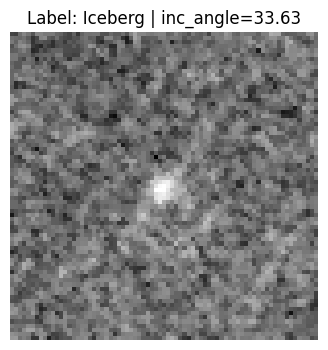

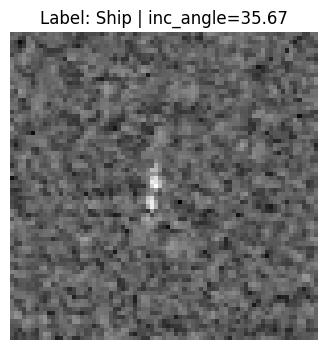

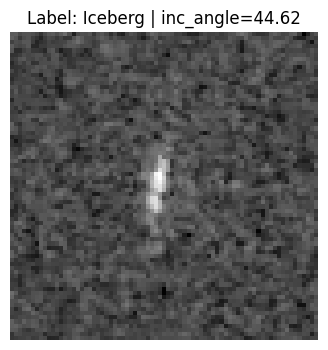

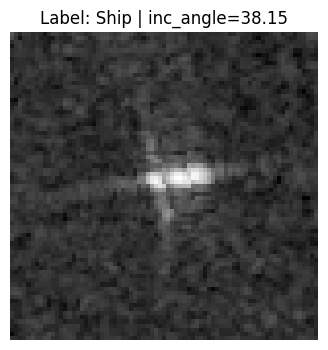

In [18]:
def show_random_examples(n=4):
    idxs = np.random.choice(len(X), size=n, replace=False)
    for idx in idxs:
        img = X[idx]
        label = int(y[idx])
        plt.figure(figsize=(4, 4))
        plt.imshow((img[0] + img[1]) / 2, cmap="gray")
        title_label = "Iceberg" if label == 1 else "Ship"
        plt.title(f"Label: {title_label} | inc_angle={train_df.loc[idx, 'inc_angle_clean']:.2f}")
        plt.axis("off")
        plt.show()

show_random_examples(4)

## 5. Dataset and augmentation

SAR images can often benefit from simple geometric augmentations. We use flips and rotations. These are cheap and GPU-friendly.

In [19]:
class IcebergDataset(Dataset):
    def __init__(self, images, angles, labels=None, augment=False):
        self.images = images
        self.angles = angles
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def _augment(self, x):
        # x is numpy C,H,W

        # Random flips
        if random.random() < 0.5:
            x = x[:, :, ::-1].copy()
        if random.random() < 0.5:
            x = x[:, ::-1, :].copy()

        # Random 90-degree rotation
        k = random.randint(0, 3)
        if k:
            x = np.rot90(x, k=k, axes=(1, 2)).copy()

        # Small spatial shift
        if random.random() < 0.60:
            shift_y = random.randint(-3, 3)
            shift_x = random.randint(-3, 3)
            x = np.roll(x, shift=(shift_y, shift_x), axis=(1, 2)).copy()

        # Slight radar intensity scaling
        if random.random() < 0.50:
            scale = np.random.uniform(0.95, 1.05)
            x = x * scale

        # Small Gaussian noise
        if random.random() < 0.50:
            noise = np.random.normal(0, 0.03, size=x.shape).astype(np.float32)
            x = x + noise

        # Small cutout
        if random.random() < 0.35:
            h, w = x.shape[1], x.shape[2]
            cut = random.randint(6, 12)
            cy = random.randint(0, h - 1)
            cx = random.randint(0, w - 1)

            y1 = max(0, cy - cut // 2)
            y2 = min(h, cy + cut // 2)
            x1 = max(0, cx - cut // 2)
            x2 = min(w, cx + cut // 2)

            x[:, y1:y2, x1:x2] = 0

        return x.astype(np.float32)

    def __getitem__(self, idx):
        img = self.images[idx]

        if self.augment:
            img = self._augment(img)

        img = torch.tensor(img, dtype=torch.float32)
        ang = torch.tensor(self.angles[idx], dtype=torch.float32)

        if self.labels is None:
            return img, ang

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, ang, label

## 6. GPU CNN model

The model combines:

- CNN image branch for 75×75 radar input
- small metadata branch for `inc_angle`
- final dense classifier

Output is a single logit. We use `BCEWithLogitsLoss`, which is numerically safer than applying sigmoid before the loss.

In [20]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, p=0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(p),
        )

    def forward(self, x):
        return self.block(x)


class IcebergCNN(nn.Module):
    def __init__(self, in_channels=5, dropout=0.50):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvBlock(in_channels, 32, p=0.08),   # 75 -> 37
            ConvBlock(32, 64, p=0.12),            # 37 -> 18
            ConvBlock(64, 128, p=0.18),           # 18 -> 9
            ConvBlock(128, 256, p=0.25),          # 9 -> 4
            nn.AdaptiveAvgPool2d(1),
        )

        self.angle_mlp = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(inplace=True),
            nn.BatchNorm1d(16),
            nn.Dropout(0.10),
        )

        self.head = nn.Sequential(
            nn.Linear(256 + 16, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout * 0.6),

            nn.Linear(64, 1),
        )

    def forward(self, img, angle):
        x = self.cnn(img).flatten(1)
        a = self.angle_mlp(angle)
        x = torch.cat([x, a], dim=1)
        return self.head(x).squeeze(1)


model = IcebergCNN(
    in_channels=CFG["channels"],
    dropout=CFG["dropout"]
).to(device)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

IcebergCNN(
  (cnn): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SiLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.08, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1),

## 7. Training and evaluation helpers

In [21]:
def smooth_labels(labels, smoothing):
    if smoothing <= 0:
        return labels
    return labels * (1.0 - smoothing) + 0.5 * smoothing


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0

    for imgs, angles, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        angles = angles.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        labels_smooth = smooth_labels(labels, CFG["label_smoothing"])

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(imgs, angles)
            loss = criterion(logits, labels_smooth)

        scaler.scale(loss).backward()

        if CFG["grad_clip"] is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []

    for batch in loader:
        if len(batch) == 3:
            imgs, angles, _ = batch
        else:
            imgs, angles = batch

        imgs = imgs.to(device, non_blocking=True)
        angles = angles.to(device, non_blocking=True)

        with autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(imgs, angles)
            probs = torch.sigmoid(logits)

        preds.append(probs.detach().cpu().numpy())

    return np.concatenate(preds)


def evaluate_predictions(y_true, preds):
    preds_clipped = np.clip(preds, CFG["pred_clip"], 1 - CFG["pred_clip"])

    metrics = {
        "log_loss": log_loss(y_true, preds_clipped),
        "accuracy": accuracy_score(y_true, preds >= 0.5),
    }

    try:
        metrics["auc"] = roc_auc_score(y_true, preds)
    except ValueError:
        metrics["auc"] = np.nan

    return metrics

## 8. K-fold GPU training

This trains one model per fold and averages the test predictions. Validation uses log loss, which matches the competition objective better than accuracy.

In [22]:
skf = StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=SEED)

oof = np.zeros(len(X), dtype=np.float32)
test_preds_folds = []
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    print(f"========== Fold {fold}/{CFG['n_folds']} ==========")

    train_ds = IcebergDataset(X[tr_idx], angle[tr_idx], y[tr_idx], augment=True)
    valid_ds = IcebergDataset(X[va_idx], angle[va_idx], y[va_idx], augment=False)
    test_ds = IcebergDataset(X_test, angle_test, labels=None, augment=False)

    train_loader = DataLoader(
        train_ds,
        batch_size=CFG["batch_size"],
        shuffle=True,
        num_workers=CFG["num_workers"],
        pin_memory=CFG["pin_memory"],
        drop_last=True,
    )

    valid_loader = DataLoader(
        valid_ds,
        batch_size=CFG["batch_size"] * 2,
        shuffle=False,
        num_workers=CFG["num_workers"],
        pin_memory=CFG["pin_memory"],
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=CFG["batch_size"] * 2,
        shuffle=False,
        num_workers=CFG["num_workers"],
        pin_memory=CFG["pin_memory"],
    )

    model = IcebergCNN(
        in_channels=CFG["channels"],
        dropout=CFG["dropout"]
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG["lr"],
        weight_decay=CFG["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    scaler = GradScaler("cuda", enabled=torch.cuda.is_available())

    best_loss = np.inf
    best_state = None
    bad_epochs = 0

    for epoch in range(1, CFG["epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)

        val_preds = predict_loader(model, valid_loader)
        val_metrics = evaluate_predictions(y[va_idx], val_preds)
        val_loss = val_metrics["log_loss"]

        scheduler.step(epoch)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:02d} | "
            f"lr={current_lr:.2e} | "
            f"train_loss={train_loss:.5f} | "
            f"val_logloss={val_loss:.5f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['auc']:.4f}"
        )

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

            if bad_epochs >= CFG["patience"]:
                print(f"Early stopping at epoch {epoch}. Best val_logloss={best_loss:.5f}")
                break

    model.load_state_dict(best_state)
    model.to(device)

    val_preds = predict_loader(model, valid_loader)
    oof[va_idx] = val_preds

    fold_metrics = evaluate_predictions(y[va_idx], val_preds)
    fold_scores.append(fold_metrics)

    print("Best fold metrics:", fold_metrics)

    fold_path = OUTPUT_DIR / f"iceberg_cnn_fold{fold}.pt"
    torch.save(model.state_dict(), fold_path)
    print("Saved:", fold_path)

    test_pred = predict_loader(model, test_loader)
    test_preds_folds.append(test_pred)

    del model, train_loader, valid_loader, test_loader
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("========== Overall OOF ==========")
oof_metrics = evaluate_predictions(y, oof)
print(oof_metrics)

pd.DataFrame(fold_scores).to_csv(OUTPUT_DIR / "fold_scores.csv", index=False)

========== Fold 1/5 ==========
Epoch 01 | lr=6.83e-04 | train_loss=0.59236 | val_logloss=0.61318 | val_acc=0.6770 | val_auc=0.8498
Epoch 02 | lr=6.33e-04 | train_loss=0.48596 | val_logloss=0.43815 | val_acc=0.8171 | val_auc=0.8808
Epoch 03 | lr=5.56e-04 | train_loss=0.48582 | val_logloss=0.39168 | val_acc=0.8482 | val_auc=0.9000
Epoch 04 | lr=4.59e-04 | train_loss=0.45533 | val_logloss=0.39066 | val_acc=0.8210 | val_auc=0.8937
Epoch 05 | lr=3.51e-04 | train_loss=0.43292 | val_logloss=0.44739 | val_acc=0.8249 | val_auc=0.8907
Epoch 06 | lr=2.42e-04 | train_loss=0.41409 | val_logloss=0.33875 | val_acc=0.8638 | val_auc=0.9245
Epoch 07 | lr=1.45e-04 | train_loss=0.42013 | val_logloss=0.31776 | val_acc=0.8638 | val_auc=0.9387
Epoch 08 | lr=6.77e-05 | train_loss=0.39382 | val_logloss=0.31753 | val_acc=0.8638 | val_auc=0.9428
Epoch 09 | lr=1.81e-05 | train_loss=0.37582 | val_logloss=0.32227 | val_acc=0.8444 | val_auc=0.9446
Epoch 10 | lr=7.00e-04 | train_loss=0.36531 | val_logloss=0.32060 | v

## 9. Optional test-time augmentation

This averages predictions over flipped/rotated versions of the test images. It often improves small image competitions a little.

In [23]:
def make_tta_images(images):
    variants = []

    # Original
    variants.append(images)

    # Flips
    variants.append(images[:, :, :, ::-1].copy())
    variants.append(images[:, :, ::-1, :].copy())

    # Rotations
    variants.append(np.rot90(images, k=1, axes=(2, 3)).copy())
    variants.append(np.rot90(images, k=2, axes=(2, 3)).copy())
    variants.append(np.rot90(images, k=3, axes=(2, 3)).copy())

    # Transpose-style variants
    variants.append(np.transpose(images, (0, 1, 3, 2)).copy())
    variants.append(np.transpose(images[:, :, ::-1, :], (0, 1, 3, 2)).copy())

    return variants


@torch.no_grad()
def predict_test_with_tta(model_path):
    model = IcebergCNN(
        in_channels=CFG["channels"],
        dropout=CFG["dropout"]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_variant_preds = []

    for X_variant in make_tta_images(X_test):
        ds = IcebergDataset(X_variant, angle_test, labels=None, augment=False)

        loader = DataLoader(
            ds,
            batch_size=CFG["batch_size"] * 2,
            shuffle=False,
            num_workers=CFG["num_workers"],
            pin_memory=CFG["pin_memory"],
        )

        all_variant_preds.append(predict_loader(model, loader))

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return np.mean(all_variant_preds, axis=0)


if CFG["tta"]:
    tta_fold_preds = []

    for fold in range(1, CFG["n_folds"] + 1):
        model_path = OUTPUT_DIR / f"iceberg_cnn_fold{fold}.pt"
        print("TTA predicting:", model_path)
        tta_fold_preds.append(predict_test_with_tta(model_path))

    test_preds = np.mean(tta_fold_preds, axis=0)

else:
    test_preds = np.mean(test_preds_folds, axis=0)

test_preds = np.clip(test_preds, CFG["pred_clip"], 1 - CFG["pred_clip"])

print(test_preds[:10])
print(test_preds.min(), test_preds.max(), test_preds.mean())

TTA predicting: outputs\iceberg_cnn_fold1.pt
TTA predicting: outputs\iceberg_cnn_fold2.pt
TTA predicting: outputs\iceberg_cnn_fold3.pt
TTA predicting: outputs\iceberg_cnn_fold4.pt
TTA predicting: outputs\iceberg_cnn_fold5.pt
[0.0213  0.9785  0.7065  0.751   0.9775  0.9307  0.978   0.8203  0.929
 0.02148]
0.010605 0.9883 0.5083


## 10. Create submission

The submission needs two columns: `id` and `is_iceberg`.

In [24]:
submission = pd.DataFrame({
    "id": test_df["id"].values,
    "is_iceberg": np.clip(test_preds, CFG["pred_clip"], 1 - CFG["pred_clip"]),
})

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission to:", submission_path)
submission.head()

Saved submission to: outputs\submission.csv


c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,is_iceberg
0,266d249e,0.021301
1,8687f19e,0.978516
2,ff9db753,0.706543
3,8f7cfa57,0.750977
4,68290b20,0.977539


In [25]:
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed.")

In [26]:
def extract_image_features(images, angles):
    """
    images shape: N, C, H, W
    Uses the 5 normalized channels:
    0 = band_1
    1 = band_2
    2 = band_1 - band_2
    3 = band_1 + band_2
    4 = abs(band_1 - band_2)
    """

    feats = []

    for i in range(images.shape[0]):
        img = images[i]
        row = []

        for c in range(img.shape[0]):
            ch = img[c]

            row.extend([
                ch.mean(),
                ch.std(),
                ch.min(),
                ch.max(),
                np.percentile(ch, 1),
                np.percentile(ch, 5),
                np.percentile(ch, 25),
                np.percentile(ch, 50),
                np.percentile(ch, 75),
                np.percentile(ch, 95),
                np.percentile(ch, 99),
                np.mean(ch > ch.mean()),
                np.mean(ch > ch.mean() + ch.std()),
                np.mean(ch < ch.mean() - ch.std()),
            ])

            # center crop stats
            center = ch[20:55, 20:55]
            row.extend([
                center.mean(),
                center.std(),
                center.max(),
                center.min(),
            ])

            # border stats
            border = np.concatenate([
                ch[:10, :].ravel(),
                ch[-10:, :].ravel(),
                ch[:, :10].ravel(),
                ch[:, -10:].ravel()
            ])

            row.extend([
                border.mean(),
                border.std(),
                border.max(),
                border.min(),
            ])

        row.append(float(angles[i][0]))
        feats.append(row)

    return np.array(feats, dtype=np.float32)


X_feat = extract_image_features(X, angle)
X_test_feat = extract_image_features(X_test, angle_test)

print(X_feat.shape, X_test_feat.shape)

(1283, 111) (321, 111)


In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

feat_oof = np.zeros(len(y), dtype=np.float32)
feat_test_preds = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_feat, y), start=1):
    print(f"Feature model fold {fold}")

    X_tr, X_va = X_feat[tr_idx], X_feat[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    if HAS_LGB:
        model = lgb.LGBMClassifier(
            n_estimators=800,
            learning_rate=0.015,
            num_leaves=12,
            max_depth=4,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="binary",
            random_state=SEED + fold,
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(80),
                lgb.log_evaluation(50),
            ],
        )

        va_pred = model.predict_proba(X_va)[:, 1]
        te_pred = model.predict_proba(X_test_feat)[:, 1]

    feat_oof[va_idx] = va_pred
    feat_test_preds.append(te_pred)

    print("fold logloss:", log_loss(y_va, np.clip(va_pred, 0.001, 0.999)))

feat_test_preds = np.mean(feat_test_preds, axis=0)

print("Feature OOF logloss:", log_loss(y, np.clip(feat_oof, 0.001, 0.999)))
print("Feature OOF AUC:", roc_auc_score(y, feat_oof))

Feature model fold 1
[LightGBM] [Info] Number of positive: 474, number of negative: 552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27177
[LightGBM] [Info] Number of data points in the train set: 1026, number of used features: 111
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.461988 -> initscore=-0.152341
[LightGBM] [Info] Start training from score -0.152341
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 80 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\TangyKiwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
cnn_oof = oof.copy()
cnn_test = test_preds.copy()

best_score = 999
best_w = None

for w in np.linspace(0, 1, 101):
    blend_oof = w * cnn_oof + (1 - w) * feat_oof
    score = log_loss(y, np.clip(blend_oof, 0.001, 0.999))

    if score < best_score:
        best_score = score
        best_w = w

print("Best CNN weight:", best_w)
print("Best blended OOF logloss:", best_score)

blend_test = best_w * cnn_test + (1 - best_w) * feat_test_preds
blend_test = np.clip(blend_test, 0.001, 0.999)

submission_blend = pd.DataFrame({
    "id": test_df["id"].values,
    "is_iceberg": blend_test,
})

submission_blend.to_csv(OUTPUT_DIR / "submission_blend_cnn_features.csv", index=False)
submission_blend.head()

Best CNN weight: 1.0
Best blended OOF logloss: 0.21435763879586522


,id,is_iceberg
0,266d249e,0.021301
1,8687f19e,0.978516
2,ff9db753,0.706543
3,8f7cfa57,0.750977
4,68290b20,0.977539


In [29]:
for clip_value in [0.0005, 0.001, 0.002, 0.005, 0.01]:
    clipped = np.clip(test_preds, clip_value, 1 - clip_value)

    sub = pd.DataFrame({
        "id": test_df["id"].values,
        "is_iceberg": clipped,
    })

    path = OUTPUT_DIR / f"submission_clip_{clip_value}.csv"
    sub.to_csv(path, index=False)
    print("Saved:", path)

Saved: outputs\submission_clip_0.0005.csv
Saved: outputs\submission_clip_0.001.csv
Saved: outputs\submission_clip_0.002.csv
Saved: outputs\submission_clip_0.005.csv
Saved: outputs\submission_clip_0.01.csv
